In [ ]:
Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import os

os.makedirs("reports", exist_ok=True)

print("✅ Libraries imported!")

# Load cleaned data
nav_history = pd.read_csv("data/processed/nav_history_clean.csv")
nav_history['Date'] = pd.to_datetime(nav_history['Date'])
nav_history = nav_history.sort_values(['Scheme', 'Date'])

print("✅ Data loaded!")
print("Shape:", nav_history.shape)
print(nav_history.head())

✅ Libraries imported!
✅ Data loaded!
Shape: (150, 4)
         Date         Scheme    Code        NAV
30 2026-04-17  Axis Bluechip  119092  6139.2351
31 2026-04-20  Axis Bluechip  119092  6142.2537
32 2026-04-21  Axis Bluechip  119092  6142.9601
33 2026-04-22  Axis Bluechip  119092  6143.3663
34 2026-04-23  Axis Bluechip  119092  6141.9603


In [ ]:
Daily Returns + CAGR

In [2]:
print("=== DAILY RETURNS & CAGR ===")

nav_pivot = nav_history.pivot_table(
    index='Date',
    columns='Scheme',
    values='NAV'
)

daily_returns = nav_pivot.pct_change().dropna()
print("✅ Daily returns calculated!")
print(daily_returns.head())

def calculate_cagr(nav_data, years):
    nav_start = nav_data.dropna().iloc[0]
    nav_end = nav_data.dropna().iloc[-1]
    n = years
    cagr = (nav_end / nav_start) ** (1/n) - 1
    return round(cagr * 100, 2)

total_days = len(nav_pivot)
years = total_days / 252

cagr_results = []
for scheme in nav_pivot.columns:
    cagr = calculate_cagr(nav_pivot[scheme], years)
    cagr_results.append({
        'Scheme': scheme,
        'CAGR_%': cagr
    })

cagr_df = pd.DataFrame(cagr_results)
cagr_df = cagr_df.sort_values('CAGR_%', ascending=False)

print("\n✅ CAGR Results:")
print(cagr_df)

=== DAILY RETURNS & CAGR ===
✅ Daily returns calculated!
Scheme      Axis Bluechip  ICICI Bluechip  Kotak Bluechip  Nippon Large Cap  \
Date                                                                          
2026-04-21       0.000115        0.009765        0.005373          0.009983   
2026-04-22       0.000066       -0.003856        0.008925         -0.003768   
2026-04-23      -0.000229       -0.006551        0.004980         -0.007666   
2026-04-24       0.000039       -0.009774       -0.006726         -0.010333   
2026-04-27       0.000063        0.009135        0.013043          0.008513   

Scheme      SBI Bluechip  
Date                      
2026-04-21      0.000096  
2026-04-22      0.000003  
2026-04-23     -0.000783  
2026-04-24     -0.000535  
2026-04-27      0.000649  

✅ CAGR Results:
             Scheme  CAGR_%
2    Kotak Bluechip   43.67
0     Axis Bluechip    2.34
4      SBI Bluechip   -0.62
1    ICICI Bluechip  -21.47
3  Nippon Large Cap  -25.57


In [ ]:
Sharpe Ratio

In [3]:
print("=== SHARPE RATIO CALCULATION ===")

rf = 0.065 / 252

sharpe_results = []
for scheme in daily_returns.columns:
    returns = daily_returns[scheme].dropna()
    
    # Sharpe = (Rp - Rf) / Std(Rp) * sqrt(252)
    excess_returns = returns - rf
    sharpe = (excess_returns.mean() / returns.std()) * np.sqrt(252)
    
    # Sortino Ratio
    downside_returns = returns[returns < 0]
    sortino = (excess_returns.mean() / downside_returns.std()) * np.sqrt(252)
    
    # Maximum Drawdown
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min() * 100
    
    sharpe_results.append({
        'Scheme': scheme,
        'Sharpe_Ratio': round(sharpe, 4),
        'Sortino_Ratio': round(sortino, 4),
        'Max_Drawdown_%': round(max_drawdown, 2)
    })

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df = sharpe_df.sort_values(
    'Sharpe_Ratio', ascending=False)

print("✅ Sharpe Ratio Results:")
print(sharpe_df)

sharpe_df.to_csv(
    'data/processed/sharpe_ratio.csv', 
    index=False)
print("\n✅ Sharpe ratio saved!")

=== SHARPE RATIO CALCULATION ===
✅ Sharpe Ratio Results:
             Scheme  Sharpe_Ratio  Sortino_Ratio  Max_Drawdown_%
2    Kotak Bluechip        2.7436         4.8060           -3.03
1    ICICI Bluechip       -2.3519        -3.2192           -4.25
3  Nippon Large Cap       -2.9821        -4.1117           -4.70
4      SBI Bluechip       -5.7968        -9.1502           -0.56
0     Axis Bluechip       -7.7037       -14.0693           -0.15

✅ Sharpe ratio saved!


In [ ]:
Alpha & Beta

In [4]:
print("=== ALPHA & BETA CALCULATION ===")

# Using Nifty 100 as benchmark
# Since we don't have Nifty data, 
# we use average of all schemes as benchmark
benchmark_returns = daily_returns.mean(axis=1)

alpha_beta_results = []
for scheme in daily_returns.columns:
    returns = daily_returns[scheme].dropna()
    
    # Align benchmark with scheme returns
    common_idx = returns.index.intersection(
        benchmark_returns.index)
    scheme_ret = returns[common_idx]
    bench_ret = benchmark_returns[common_idx]
    
    # OLS Regression
    slope, intercept, r_value, p_value, std_err = \
        stats.linregress(bench_ret, scheme_ret)
    
    # Beta = slope
    # Alpha = intercept * 252
    beta = round(slope, 4)
    alpha = round(intercept * 252 * 100, 4)
    r_squared = round(r_value**2, 4)
    
    alpha_beta_results.append({
        'Scheme': scheme,
        'Alpha_%': alpha,
        'Beta': beta,
        'R_Squared': r_squared
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
print("✅ Alpha & Beta Results:")
print(alpha_beta_df)

# Save to CSV
alpha_beta_df.to_csv(
    'data/processed/alpha_beta.csv',
    index=False)
print("\n✅ Alpha Beta saved!")

=== ALPHA & BETA CALCULATION ===
✅ Alpha & Beta Results:
             Scheme  Alpha_%    Beta  R_Squared
0     Axis Bluechip   2.0467 -0.0015     0.0004
1    ICICI Bluechip -20.5415  1.7274     0.9392
2    Kotak Bluechip  47.3313  1.5394     0.7379
3  Nippon Large Cap -27.9162  1.6619     0.9251
4      SBI Bluechip  -0.9204  0.0727     0.1731

✅ Alpha Beta saved!


In [ ]:
Fund Scorecard

In [5]:
print("=== FUND SCORECARD ===")

# Merge all metrics
scorecard = cagr_df.copy()
scorecard = scorecard.merge(sharpe_df, on='Scheme')
scorecard = scorecard.merge(alpha_beta_df, on='Scheme')

# Rank each metric
scorecard['CAGR_Rank'] = scorecard['CAGR_%'].rank(ascending=False)
scorecard['Sharpe_Rank'] = scorecard['Sharpe_Ratio'].rank(ascending=False)
scorecard['Alpha_Rank'] = scorecard['Alpha_%'].rank(ascending=False)
scorecard['DD_Rank'] = scorecard['Max_Drawdown_%'].rank(ascending=True)

# Calculate composite score
# 30% CAGR + 25% Sharpe + 20% Alpha + 15% DD + 10% Beta
scorecard['Composite_Score'] = (
    (scorecard['CAGR_Rank'] * 0.30) +
    (scorecard['Sharpe_Rank'] * 0.25) +
    (scorecard['Alpha_Rank'] * 0.20) +
    (scorecard['DD_Rank'] * 0.15)
).round(2)

# Final ranking
scorecard['Final_Rank'] = scorecard[
    'Composite_Score'].rank(ascending=True)
scorecard = scorecard.sort_values('Final_Rank')

print("✅ Fund Scorecard:")
print(scorecard[['Scheme','CAGR_%',
                  'Sharpe_Ratio','Alpha_%',
                  'Max_Drawdown_%',
                  'Composite_Score',
                  'Final_Rank']])

scorecard.to_csv(
    'data/processed/fund_scorecard.csv',
    index=False)
print("\n✅ Fund Scorecard saved!")

=== FUND SCORECARD ===
✅ Fund Scorecard:
             Scheme  CAGR_%  Sharpe_Ratio  Alpha_%  Max_Drawdown_%  \
0    Kotak Bluechip   43.67        2.7436  47.3313           -3.03   
3    ICICI Bluechip  -21.47       -2.3519 -20.5415           -4.25   
1     Axis Bluechip    2.34       -7.7037   2.0467           -0.15   
2      SBI Bluechip   -0.62       -5.7968  -0.9204           -0.56   
4  Nippon Large Cap  -25.57       -2.9821 -27.9162           -4.70   

   Composite_Score  Final_Rank  
0              1.2         1.0  
3              2.8         2.0  
1              3.0         3.0  
2              3.1         4.0  
4              3.4         5.0  

✅ Fund Scorecard saved!


In [ ]:
Performance Charts

=== PERFORMANCE CHARTS ===


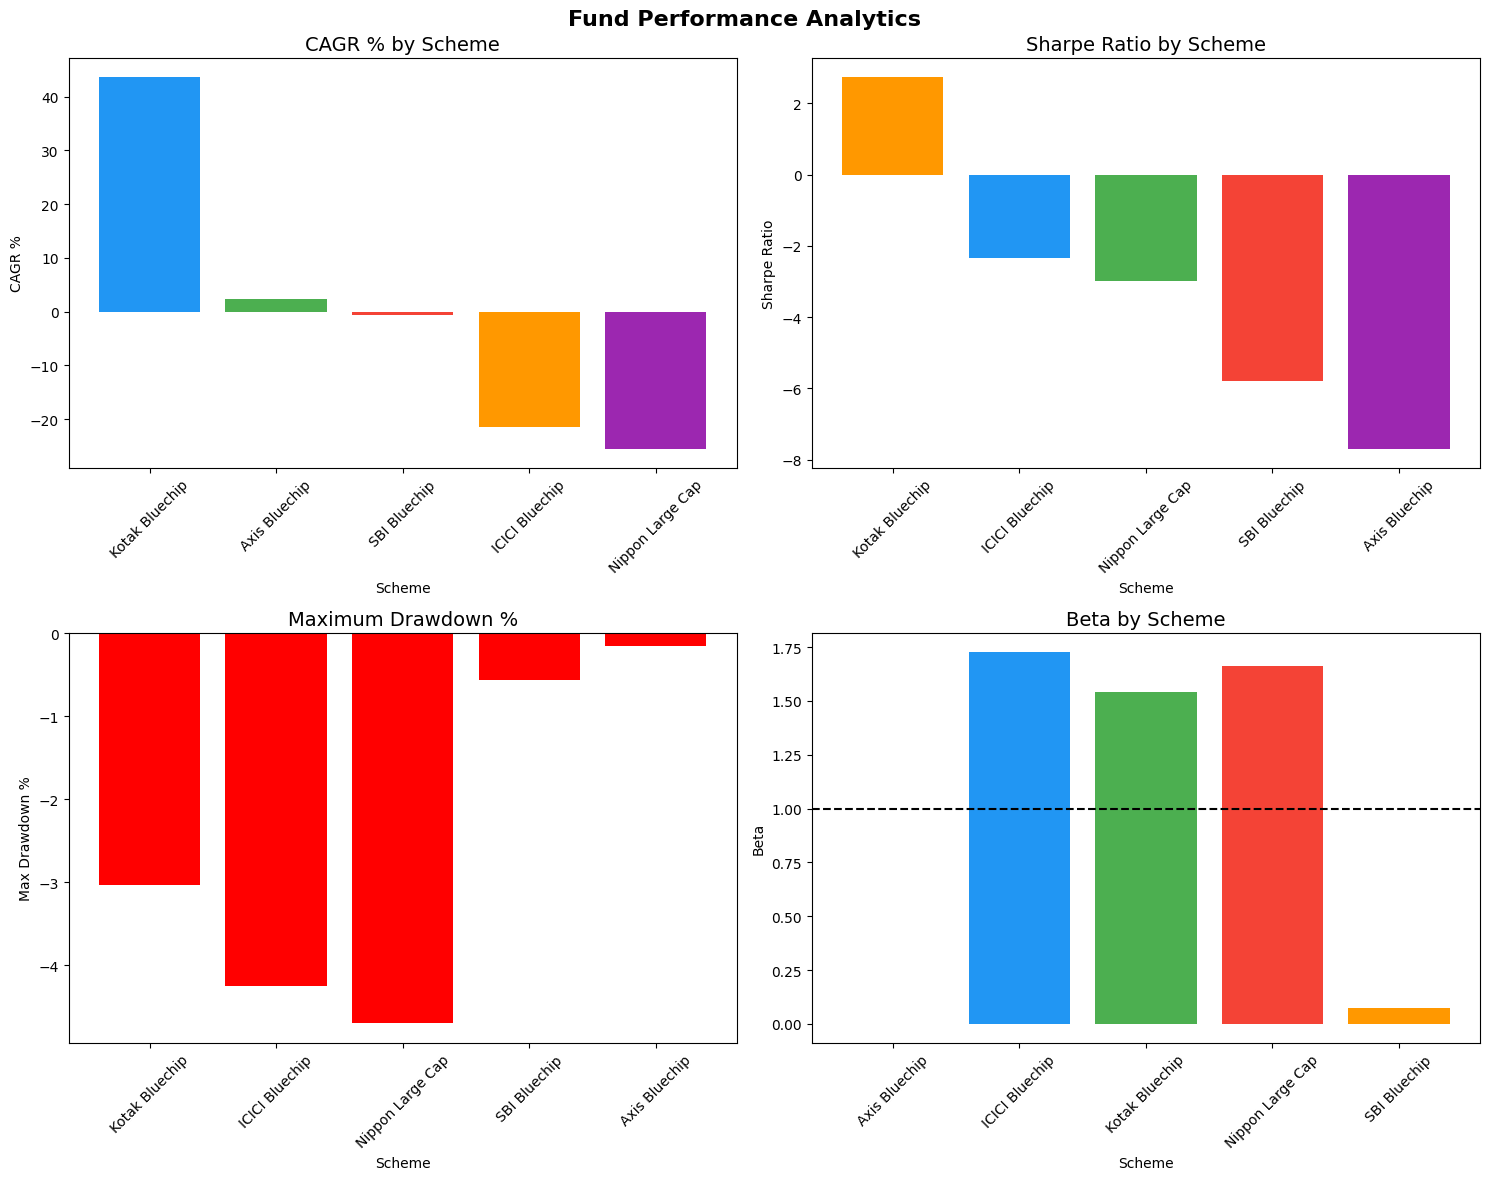

✅ Performance charts saved!


In [6]:
# Chart 1 - CAGR Comparison
print("=== PERFORMANCE CHARTS ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Chart 1 - CAGR Bar Chart
axes[0,0].bar(cagr_df['Scheme'], 
              cagr_df['CAGR_%'],
              color=['#2196F3','#4CAF50',
                     '#F44336','#FF9800','#9C27B0'])
axes[0,0].set_title('CAGR % by Scheme', fontsize=14)
axes[0,0].set_xlabel('Scheme')
axes[0,0].set_ylabel('CAGR %')
axes[0,0].tick_params(axis='x', rotation=45)

# Chart 2 - Sharpe Ratio
axes[0,1].bar(sharpe_df['Scheme'],
              sharpe_df['Sharpe_Ratio'],
              color=['#FF9800','#2196F3',
                     '#4CAF50','#F44336','#9C27B0'])
axes[0,1].set_title('Sharpe Ratio by Scheme', fontsize=14)
axes[0,1].set_xlabel('Scheme')
axes[0,1].set_ylabel('Sharpe Ratio')
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3 - Max Drawdown
axes[1,0].bar(sharpe_df['Scheme'],
              sharpe_df['Max_Drawdown_%'],
              color='red')
axes[1,0].set_title('Maximum Drawdown %', fontsize=14)
axes[1,0].set_xlabel('Scheme')
axes[1,0].set_ylabel('Max Drawdown %')
axes[1,0].tick_params(axis='x', rotation=45)

# Chart 4 - Beta Comparison
axes[1,1].bar(alpha_beta_df['Scheme'],
              alpha_beta_df['Beta'],
              color=['#9C27B0','#2196F3',
                     '#4CAF50','#F44336','#FF9800'])
axes[1,1].set_title('Beta by Scheme', fontsize=14)
axes[1,1].set_xlabel('Scheme')
axes[1,1].set_ylabel('Beta')
axes[1,1].axhline(y=1, color='black', 
                   linestyle='--', 
                   label='Beta=1')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Fund Performance Analytics', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/performance_charts.png', dpi=150)
plt.show()

print("✅ Performance charts saved!")

In [ ]:
Benchmark Comparison Chart

=== BENCHMARK COMPARISON ===


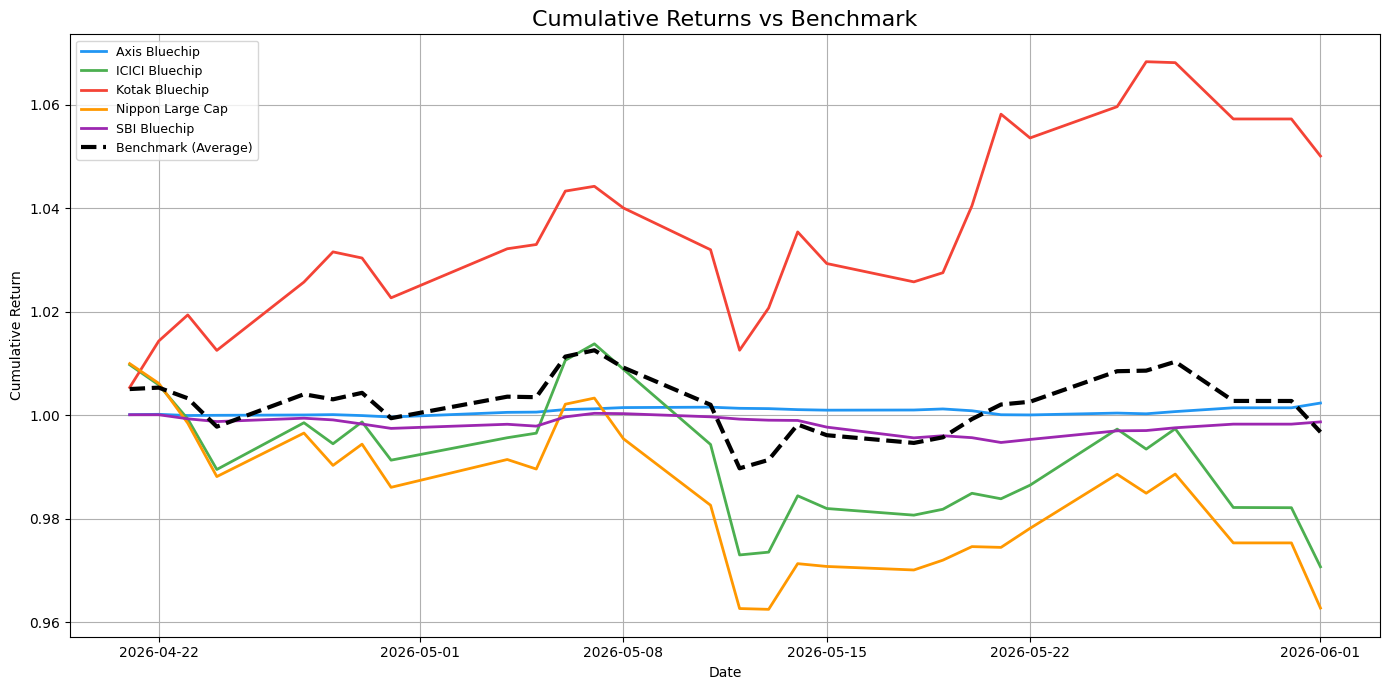

✅ Benchmark comparison chart saved!


In [7]:
print("=== BENCHMARK COMPARISON ===")

cumulative_returns = (1 + daily_returns).cumprod()

plt.figure(figsize=(14, 7))

colors = ['#2196F3','#4CAF50',
          '#F44336','#FF9800','#9C27B0']

for i, scheme in enumerate(cumulative_returns.columns):
    plt.plot(cumulative_returns.index,
             cumulative_returns[scheme],
             label=scheme,
             linewidth=2,
             color=colors[i])

benchmark_cumulative = (1 + benchmark_returns).cumprod()
plt.plot(benchmark_cumulative.index,
         benchmark_cumulative.values,
         label='Benchmark (Average)',
         linewidth=3,
         color='black',
         linestyle='--')

plt.title('Cumulative Returns vs Benchmark',
          fontsize=16)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.savefig('reports/benchmark_comparison.png', dpi=150)
plt.show()

print("✅ Benchmark comparison chart saved!")

In [ ]:
Save All Results

In [8]:
print("=== DAY 4 COMPLETE ===")

print("\n📊 Performance Metrics Summary:")
print("\nTop Performing Fund (CAGR):")
print(cagr_df.iloc[0])

print("\nBest Sharpe Ratio:")
print(sharpe_df.iloc[0])

print("\nBest Alpha:")
print(alpha_beta_df.nlargest(1, 'Alpha_%'))

print("\n✅ All files saved:")
print("  - data/processed/fund_scorecard.csv")
print("  - data/processed/sharpe_ratio.csv")
print("  - data/processed/alpha_beta.csv")
print("  - reports/performance_charts.png")
print("  - reports/benchmark_comparison.png")
print("\n✅ Day 4 Performance Analytics Complete!")

=== DAY 4 COMPLETE ===

📊 Performance Metrics Summary:

Top Performing Fund (CAGR):
Scheme    Kotak Bluechip
CAGR_%             43.67
Name: 2, dtype: object

Best Sharpe Ratio:
Scheme            Kotak Bluechip
Sharpe_Ratio              2.7436
Sortino_Ratio              4.806
Max_Drawdown_%             -3.03
Name: 2, dtype: object

Best Alpha:
           Scheme  Alpha_%    Beta  R_Squared
2  Kotak Bluechip  47.3313  1.5394     0.7379

✅ All files saved:
  - data/processed/fund_scorecard.csv
  - data/processed/sharpe_ratio.csv
  - data/processed/alpha_beta.csv
  - reports/performance_charts.png
  - reports/benchmark_comparison.png

✅ Day 4 Performance Analytics Complete!
